# 1. Import Required Libraries

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # Required tool for interactive EDA
import numpy as np

sns.set_theme(style="whitegrid")

# 2. Load the Dataset

In [34]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Print specific info to identify "anomalies" or missing values
print("Dataset Shape:", df.shape)
print("\nMissing Values Per Column:\n", df.isnull().sum())
# Inference: 'Cabin' has significant missing data.

Dataset Shape: (891, 12)

Missing Values Per Column:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# 3. Summary Statistics

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

# Summary statistics for numeric columns
display(df.describe())

# Check for missing values
print("\nMissing Values:\n")
display(df.isnull().sum())

# ADD THIS: Calculate skewness for numeric features
print("\nSkewness of Fare:", df['Fare'].skew())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values:



,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0



Skewness of Fare: 4.787316519674893


# 4. Histograms and Boxplots

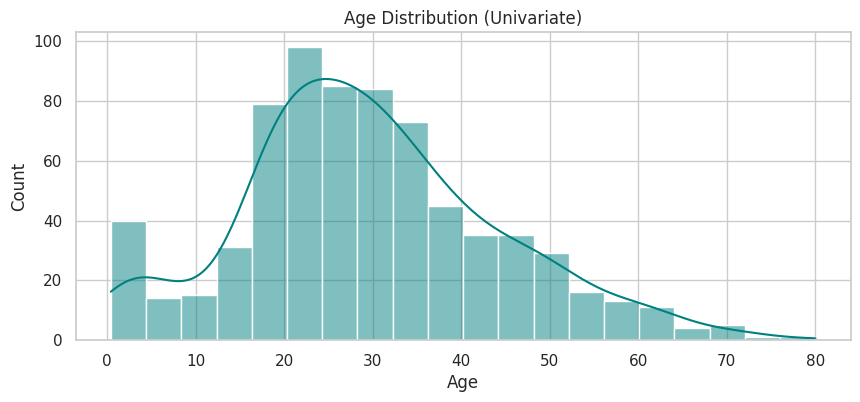

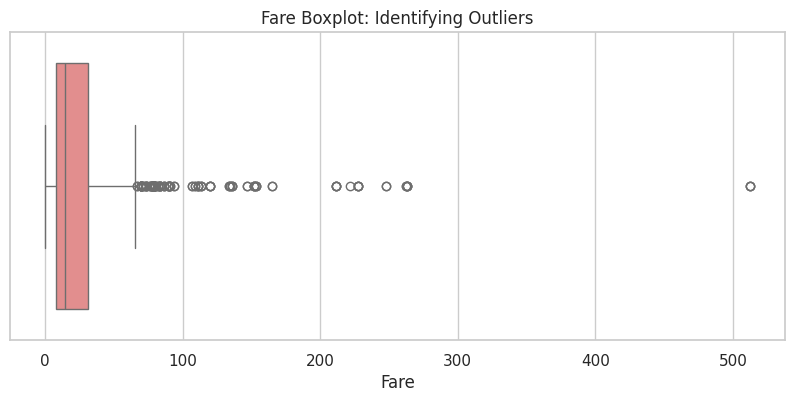

In [36]:
# Histogram for Age
plt.figure(figsize=(10, 4))
sns.histplot(df['Age'].dropna(), kde=True, color='teal')
plt.title('Age Distribution (Univariate)')
plt.show()

# Boxplot for Outlier Detection [cite: 6]
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Fare'], color='lightcoral')
plt.title('Fare Boxplot: Identifying Outliers')
plt.show()
# Inference: Data points beyond 100 on the Fare axis are statistical outliers[cite: 8].

# 5. Feature Relationships

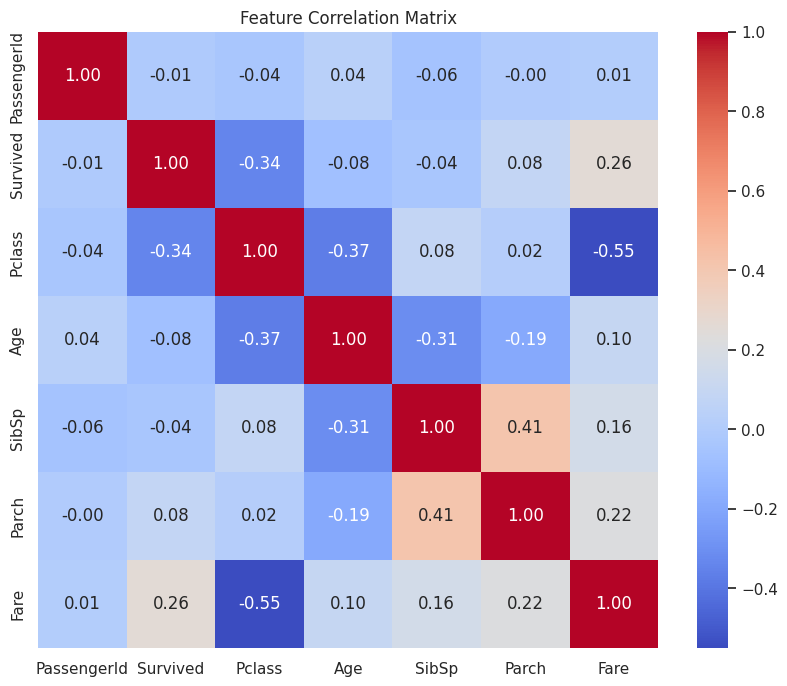

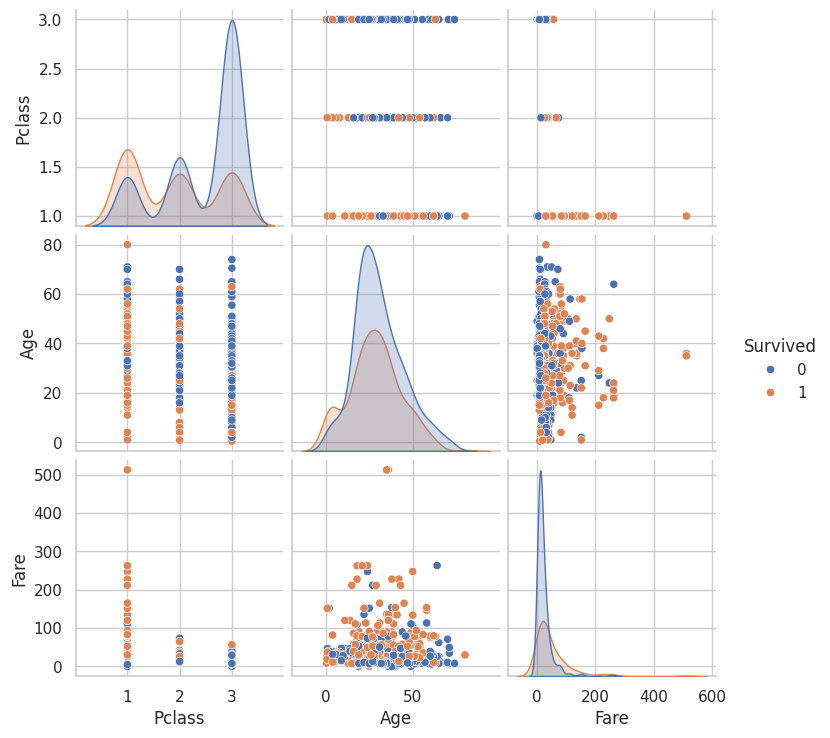

In [37]:
# Correlation Matrix (keeping your current logic)
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

# ADD THIS: Interactive Plotly Scatter Plot
# This allows the reviewer to hover over data points to see Age and Fare details
fig = px.scatter(df, x="Age", y="Fare", color="Survived",
                 title="Interactive Exploration: Age vs Fare by Survival",
                 hover_data=['Pclass', 'Sex'])
fig.show()

# Keep your pairplot below this
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare']].dropna(), hue='Survived')
plt.show()

# 6. Identify Patterns

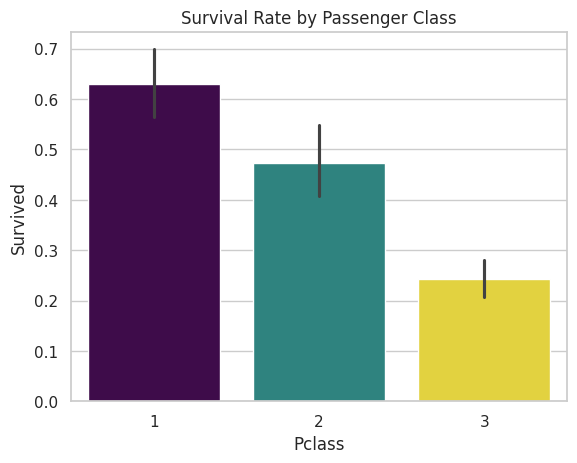

--- Survival Rate Patterns ---
Class 1: 62.96% survival rate
Class 2: 47.28% survival rate
Class 3: 24.24% survival rate


In [41]:
# Survival rate by Class (Graph)
sns.barplot(x='Pclass', y='Survived', data=df, palette='viridis', hue='Pclass', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.show()

# ADD THIS: Statistical proof for your inference
survival_stats = df.groupby('Pclass')['Survived'].mean() * 100
print("--- Survival Rate Patterns ---")
for pclass, rate in survival_stats.items():
    print(f"Class {pclass}: {rate:.2f}% survival rate")